# 1.0 EDA e Limpeza de Dados — AirQualityUCI

Neste notebook é realizada a análise exploratória dos dados e a preparação inicial do dataset **AirQualityUCI**, no âmbito da unidade curricular de Projeto em Ciência de Dados.


In [1]:
import pandas as pd
import seaborn as sns

CSV_PATH = "/kaggle/input/datasets/jhonan/airqualityuci/AirQualityUCI.csv"

df = pd.read_csv(CSV_PATH, sep=';', decimal=',')
df = df.dropna(axis=1, how='all').dropna(axis=0, how='all')

print("Dimensão:", df.shape)
display(df.head())

Dimensão: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [2]:

df.info()

import numpy as np
display(df.describe(include=[np.number]).T)

<class 'pandas.core.frame.DataFrame'>
Index: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


,count,mean,std,min,25%,50%,75%,max
CO(GT),9357.0,-34.207524,77.657170,-200.0,0.6000,1.5000,2.6000,11.900
PT08.S1(CO),9357.0,1048.990061,329.832710,-200.0,921.0000,1053.0000,1221.0000,2040.000
NMHC(GT),9357.0,-159.090093,139.789093,-200.0,-200.0000,-200.0000,-200.0000,1189.000
C6H6(GT),9357.0,1.865683,41.380206,-200.0,4.0000,7.9000,13.6000,63.700
PT08.S2(NMHC),9357.0,894.595276,342.333252,-200.0,711.0000,895.0000,1105.0000,2214.000
NOx(GT),9357.0,168.616971,257.433866,-200.0,50.0000,141.0000,284.0000,1479.000
PT08.S3(NOx),9357.0,794.990168,321.993552,-200.0,637.0000,794.0000,960.0000,2683.000
NO2(GT),9357.0,58.148873,126.940455,-200.0,53.0000,96.0000,133.0000,340.000
PT08.S4(NO2),9357.0,1391.479641,467.210125,-200.0,1185.0000,1446.0000,1662.0000,2775.000
PT08.S5(O3),9357.0,975.072032,456.938184,-200.0,700.0000,942.0000,1255.0000,2523.000


## Preparação Inicial dos Dados

Nesta fase foi criada uma cópia de trabalho do dataset (`df_clean`) e foram aplicadas transformações iniciais importantes para a análise exploratória.

Em particular:
- os valores `-200` foram convertidos para `NaN`, por representarem ausência de medição;
- as colunas `Date` e `Time` foram combinadas numa variável temporal `timestamp`, permitindo uma representação cronológica mais adequada dos registos.

In [3]:
import numpy as np
import pandas as pd

df_clean = df.copy()

# Substituir -200 por NaN nas colunas numéricas
numeric_cols = [c for c in df_clean.columns if c not in ["Date", "Time"]]
df_clean[numeric_cols] = df_clean[numeric_cols].replace(-200, np.nan)

# Criar timestamp
df_clean["timestamp"] = pd.to_datetime(
    df_clean["Date"].astype(str).str.strip() + " " + df_clean["Time"].astype(str).str.strip(),
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# Tabela de missing values
missing_table = pd.DataFrame({
    "missing_count": df_clean.isna().sum(),
    "missing_pct": (df_clean.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

display(missing_table)

# Tipos de dados
print(df_clean.dtypes)

,missing_count,missing_pct
NMHC(GT),8443,90.23
CO(GT),1683,17.99
NO2(GT),1642,17.55
NOx(GT),1639,17.52
C6H6(GT),366,3.91
PT08.S2(NMHC),366,3.91
PT08.S3(NOx),366,3.91
PT08.S1(CO),366,3.91
T,366,3.91
RH,366,3.91


Date                     object
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
timestamp        datetime64[ns]
dtype: object


## Análise Univariada

Nesta secção são analisadas as variáveis numéricas através de histogramas e boxplots, com o objetivo de compreender a distribuição dos dados, identificar assimetrias e detetar possíveis valores atípicos.

Adicionalmente, é analisada a frequência das variáveis não numéricas `Date` e `Time`, de modo a verificar a regularidade temporal dos registos.

Variáveis numéricas analisadas:
['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


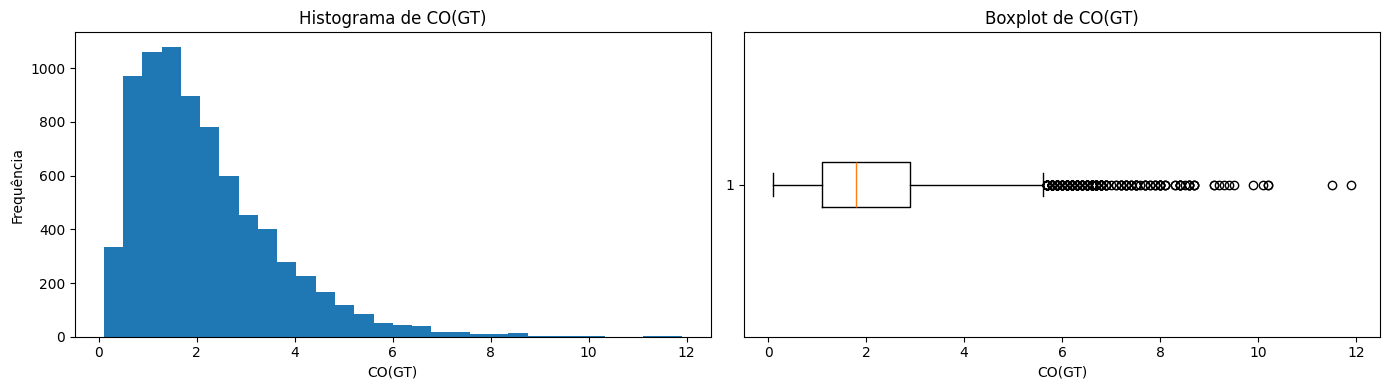

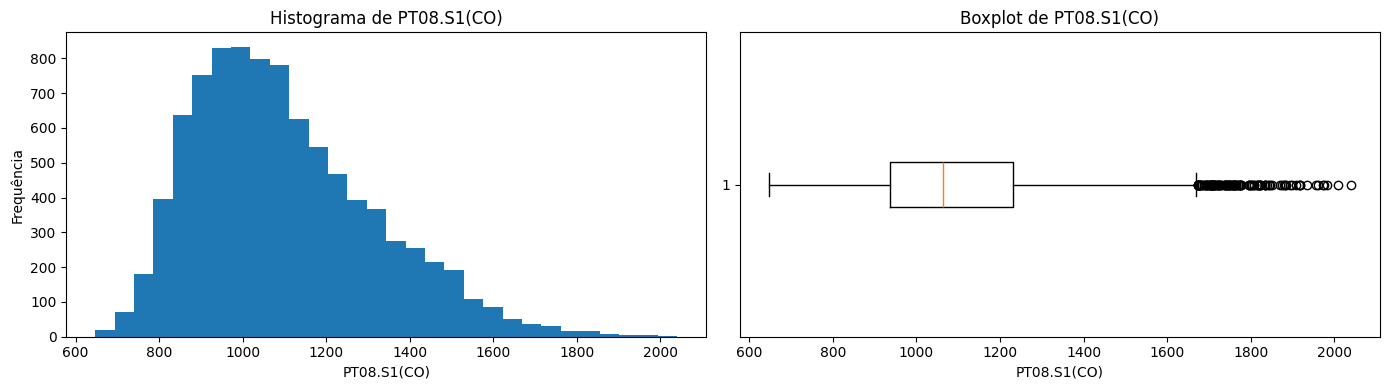

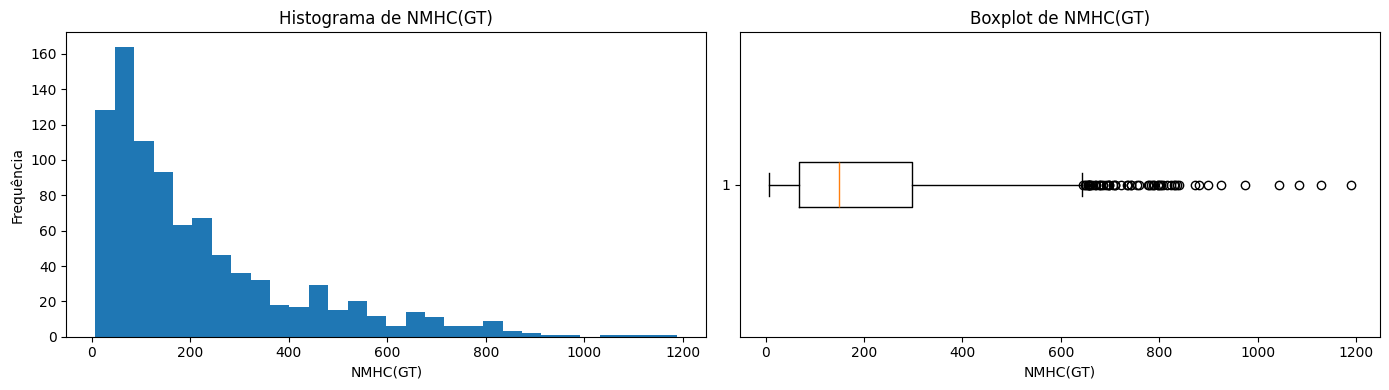

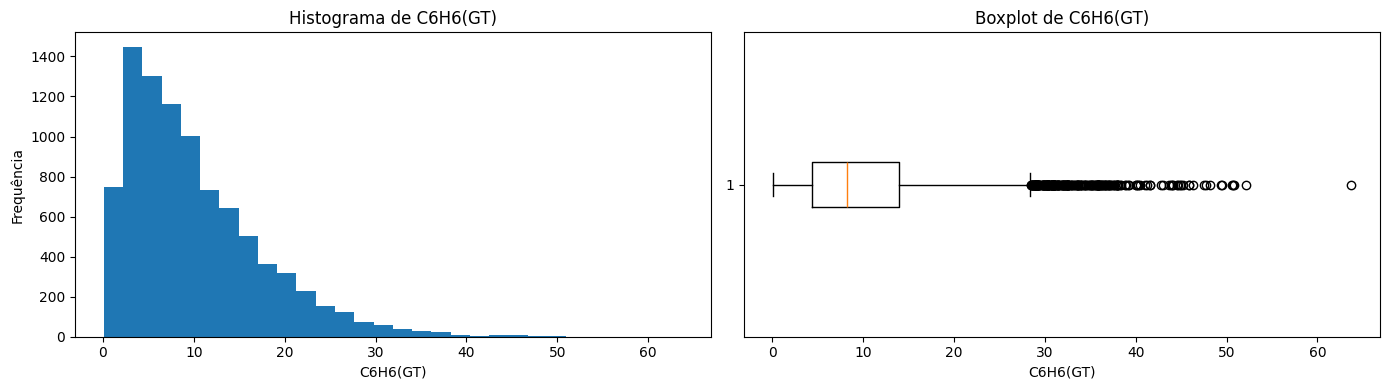

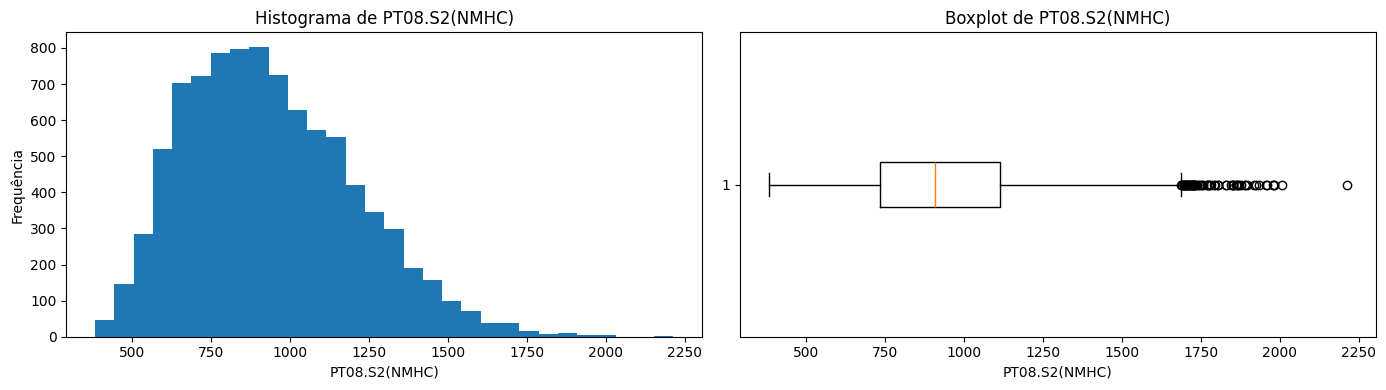

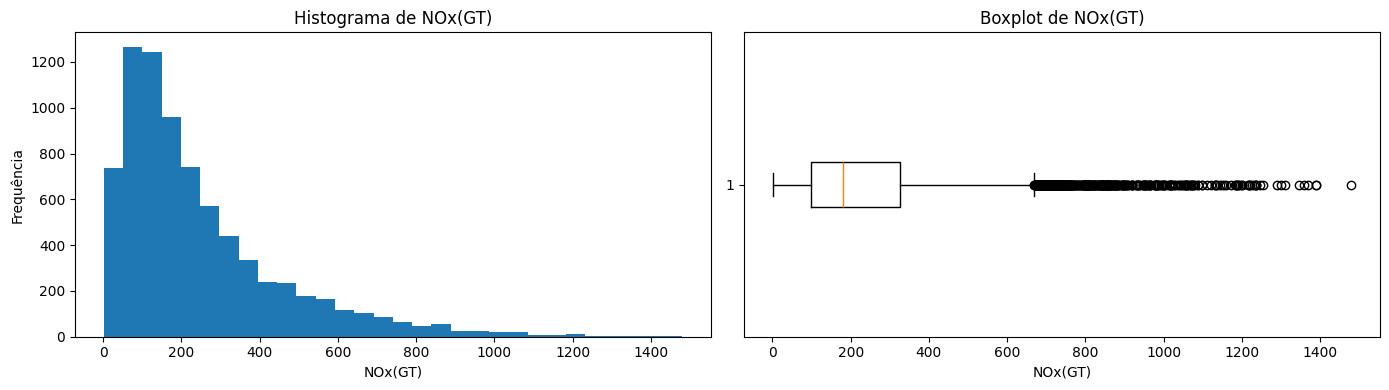

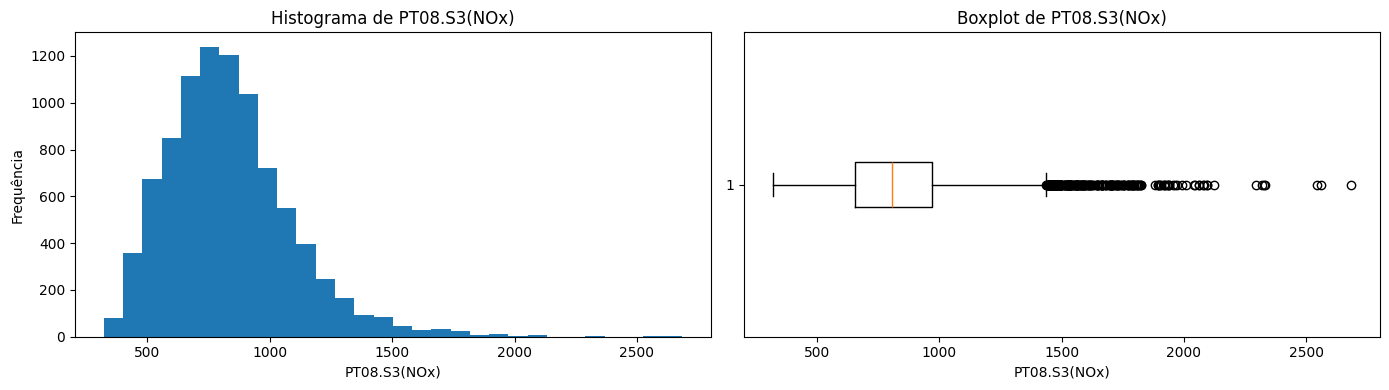

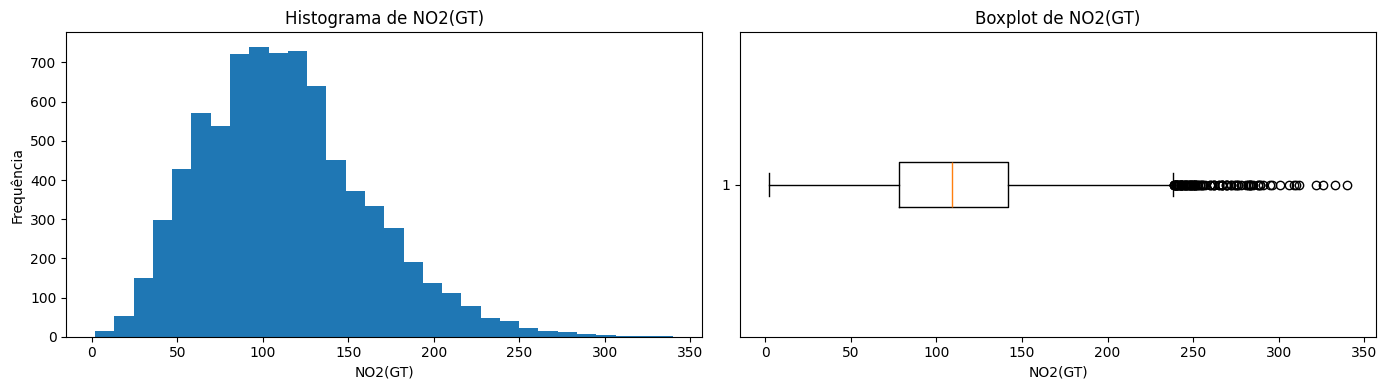

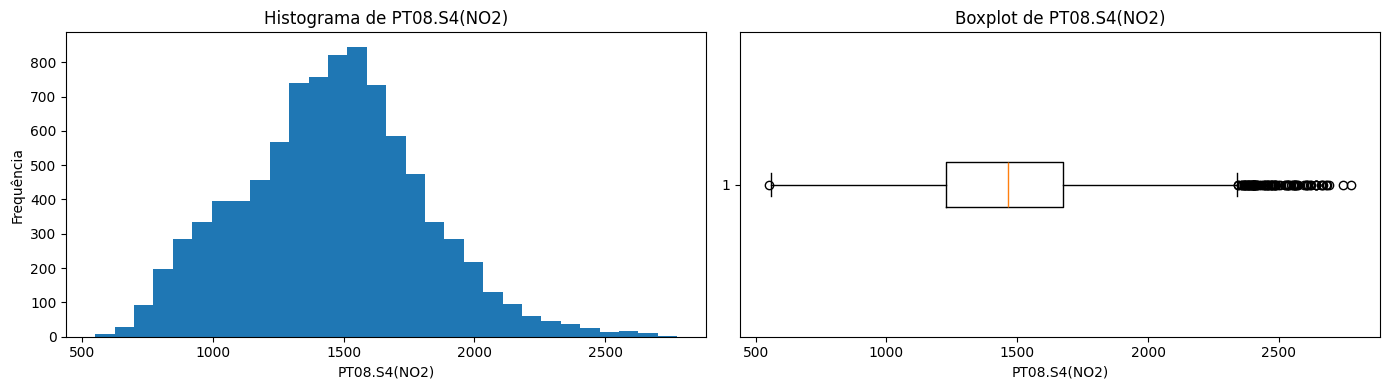

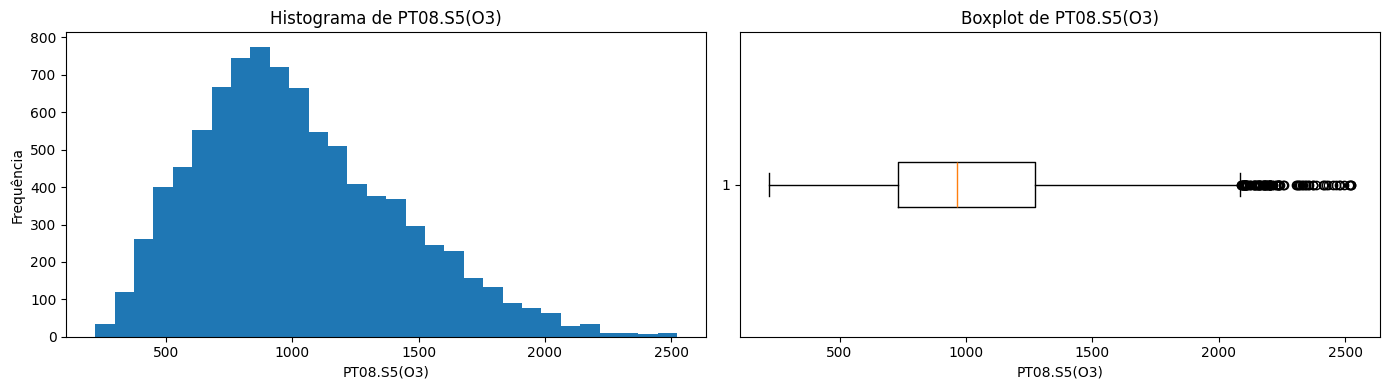

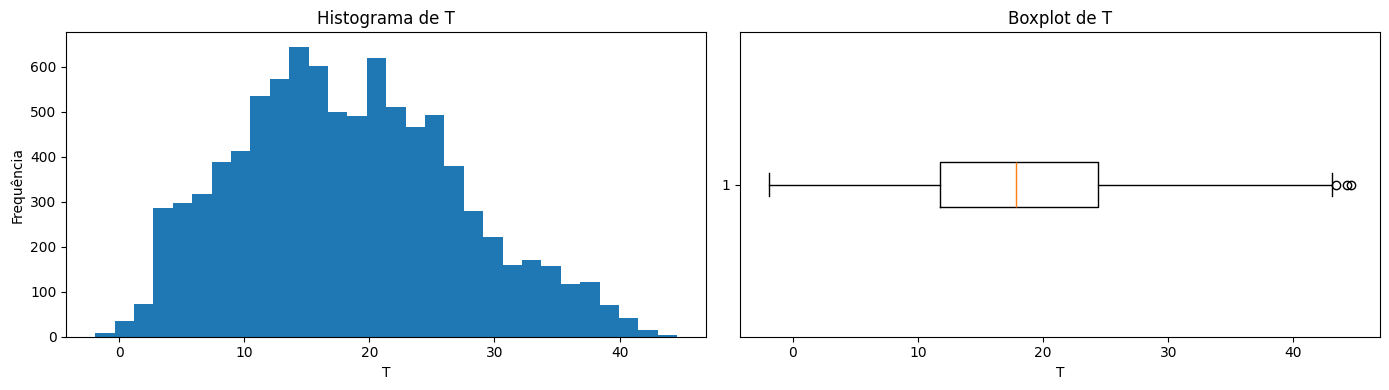

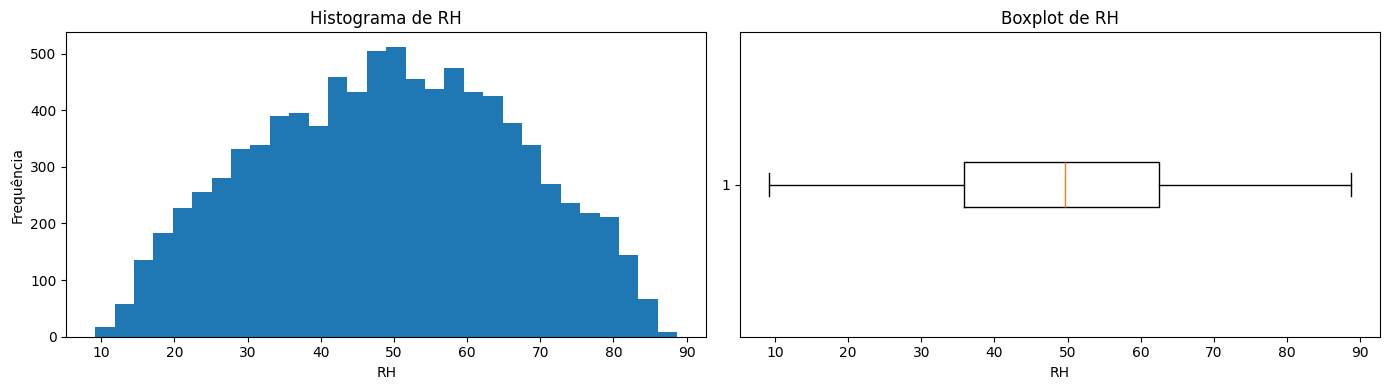

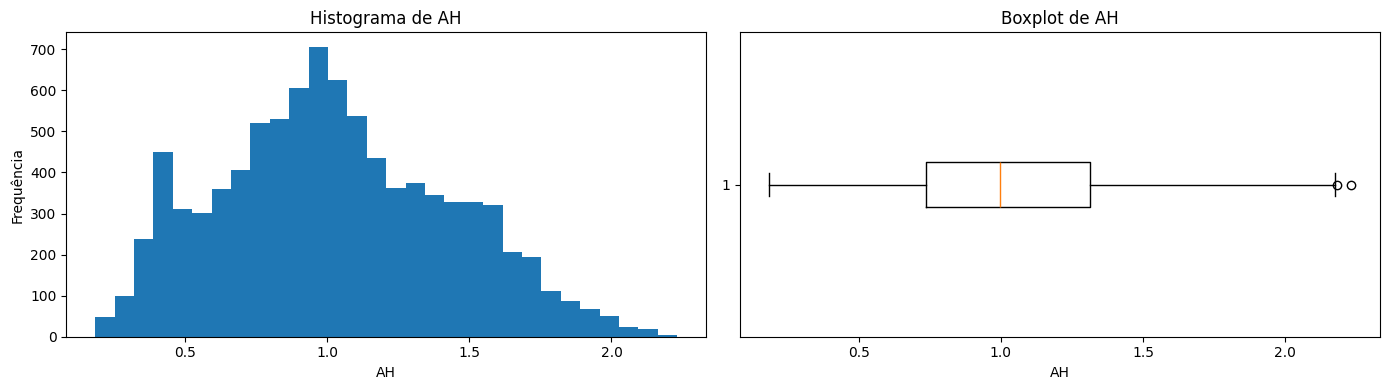

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Selecionar apenas variáveis numéricas
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Variáveis numéricas analisadas:")
print(numeric_features)

# Criar um par de gráficos por variável:
# à esquerda = histograma | à direita = boxplot
for col in numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Histograma
    axes[0].hist(df_clean[col].dropna(), bins=30)
    axes[0].set_title(f"Histograma de {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequência")

    # Boxplot
    axes[1].boxplot(df_clean[col].dropna(), vert=False)
    axes[1].set_title(f"Boxplot de {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()


Frequência de Date:
Date
03/04/2005    24
02/04/2005    24
11/03/2004    24
12/03/2004    24
13/03/2004    24
17/03/2005    24
16/03/2005    24
15/03/2005    24
14/03/2005    24
13/03/2005    24
12/03/2005    24
11/03/2005    24
10/03/2005    24
09/03/2005    24
08/03/2005    24
07/03/2005    24
06/03/2005    24
05/03/2005    24
04/03/2005    24
03/03/2005    24
Name: count, dtype: int64


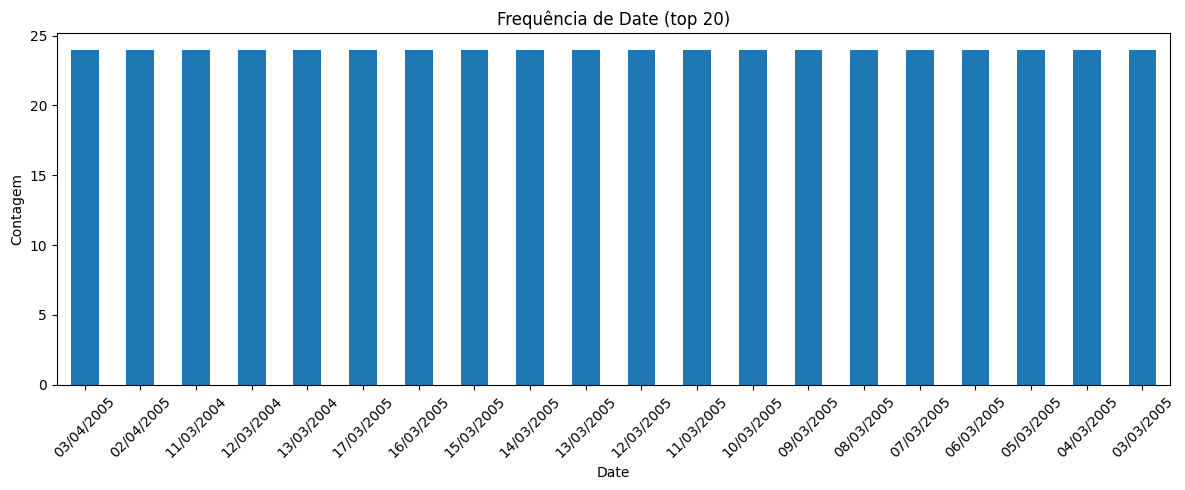


Frequência de Time:
Time
18.00.00    390
19.00.00    390
20.00.00    390
21.00.00    390
22.00.00    390
23.00.00    390
00.00.00    390
01.00.00    390
02.00.00    390
03.00.00    390
04.00.00    390
05.00.00    390
06.00.00    390
07.00.00    390
08.00.00    390
09.00.00    390
10.00.00    390
11.00.00    390
12.00.00    390
13.00.00    390
Name: count, dtype: int64


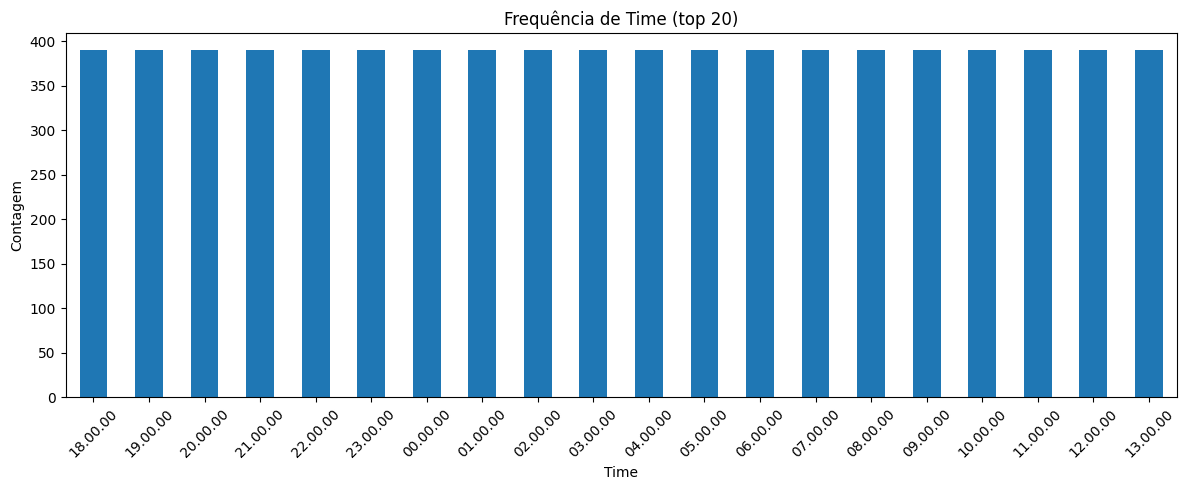

In [5]:
import matplotlib.pyplot as plt

# Variáveis categóricas
categorical_features = ["Date", "Time"]

for col in categorical_features:
    print(f"\nFrequência de {col}:")
    print(df_clean[col].value_counts().head(20))

    plt.figure(figsize=(12, 5))
    df_clean[col].value_counts().head(20).plot(kind="bar")
    plt.title(f"Frequência de {col} (top 20)")
    plt.xlabel(col)
    plt.ylabel("Contagem")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Principais observações da análise univariada

A análise univariada mostrou que a variável-alvo `CO(GT)` apresenta maior concentração de valores baixos e alguns valores mais elevados, o que sugere uma distribuição assimétrica. Os boxplots indicaram também a presença de possíveis outliers em várias variáveis numéricas.

Relativamente às variáveis `Date` e `Time`, a análise de frequência mostrou que o dataset apresenta uma estrutura temporal regular, sendo frequente a existência de 24 registos por dia, o que é consistente com medições horárias.

## Análise Bivariada e Correlações

Nesta secção é analisada a relação entre a variável-alvo `CO(GT)` e os restantes atributos numéricos. Para isso, é utilizada uma matriz de correlação e gráficos de dispersão.

O objetivo é identificar quais as variáveis com maior potencial explicativo para a fase de modelação e compreender a intensidade e o sentido das relações observadas.

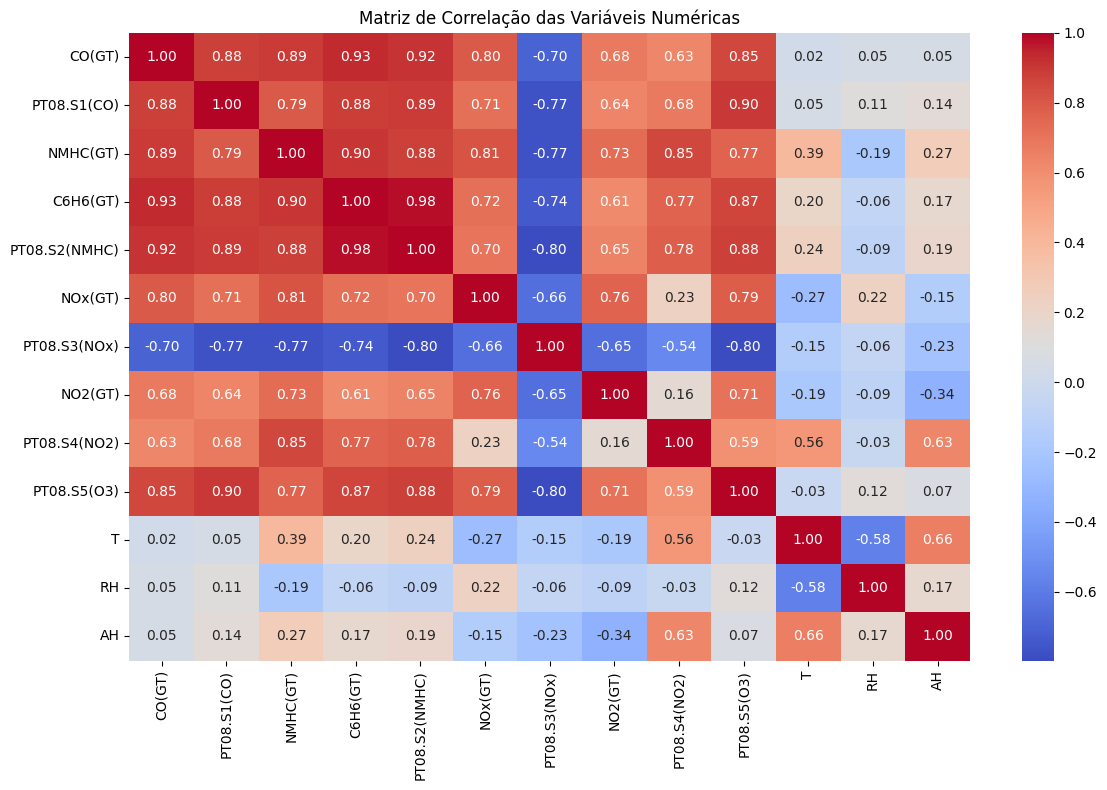

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Selecionar apenas variáveis numéricas
numeric_features = df_clean.select_dtypes(include=[np.number])

# Matriz de correlação
corr_matrix = numeric_features.corr()

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.tight_layout()
plt.show()

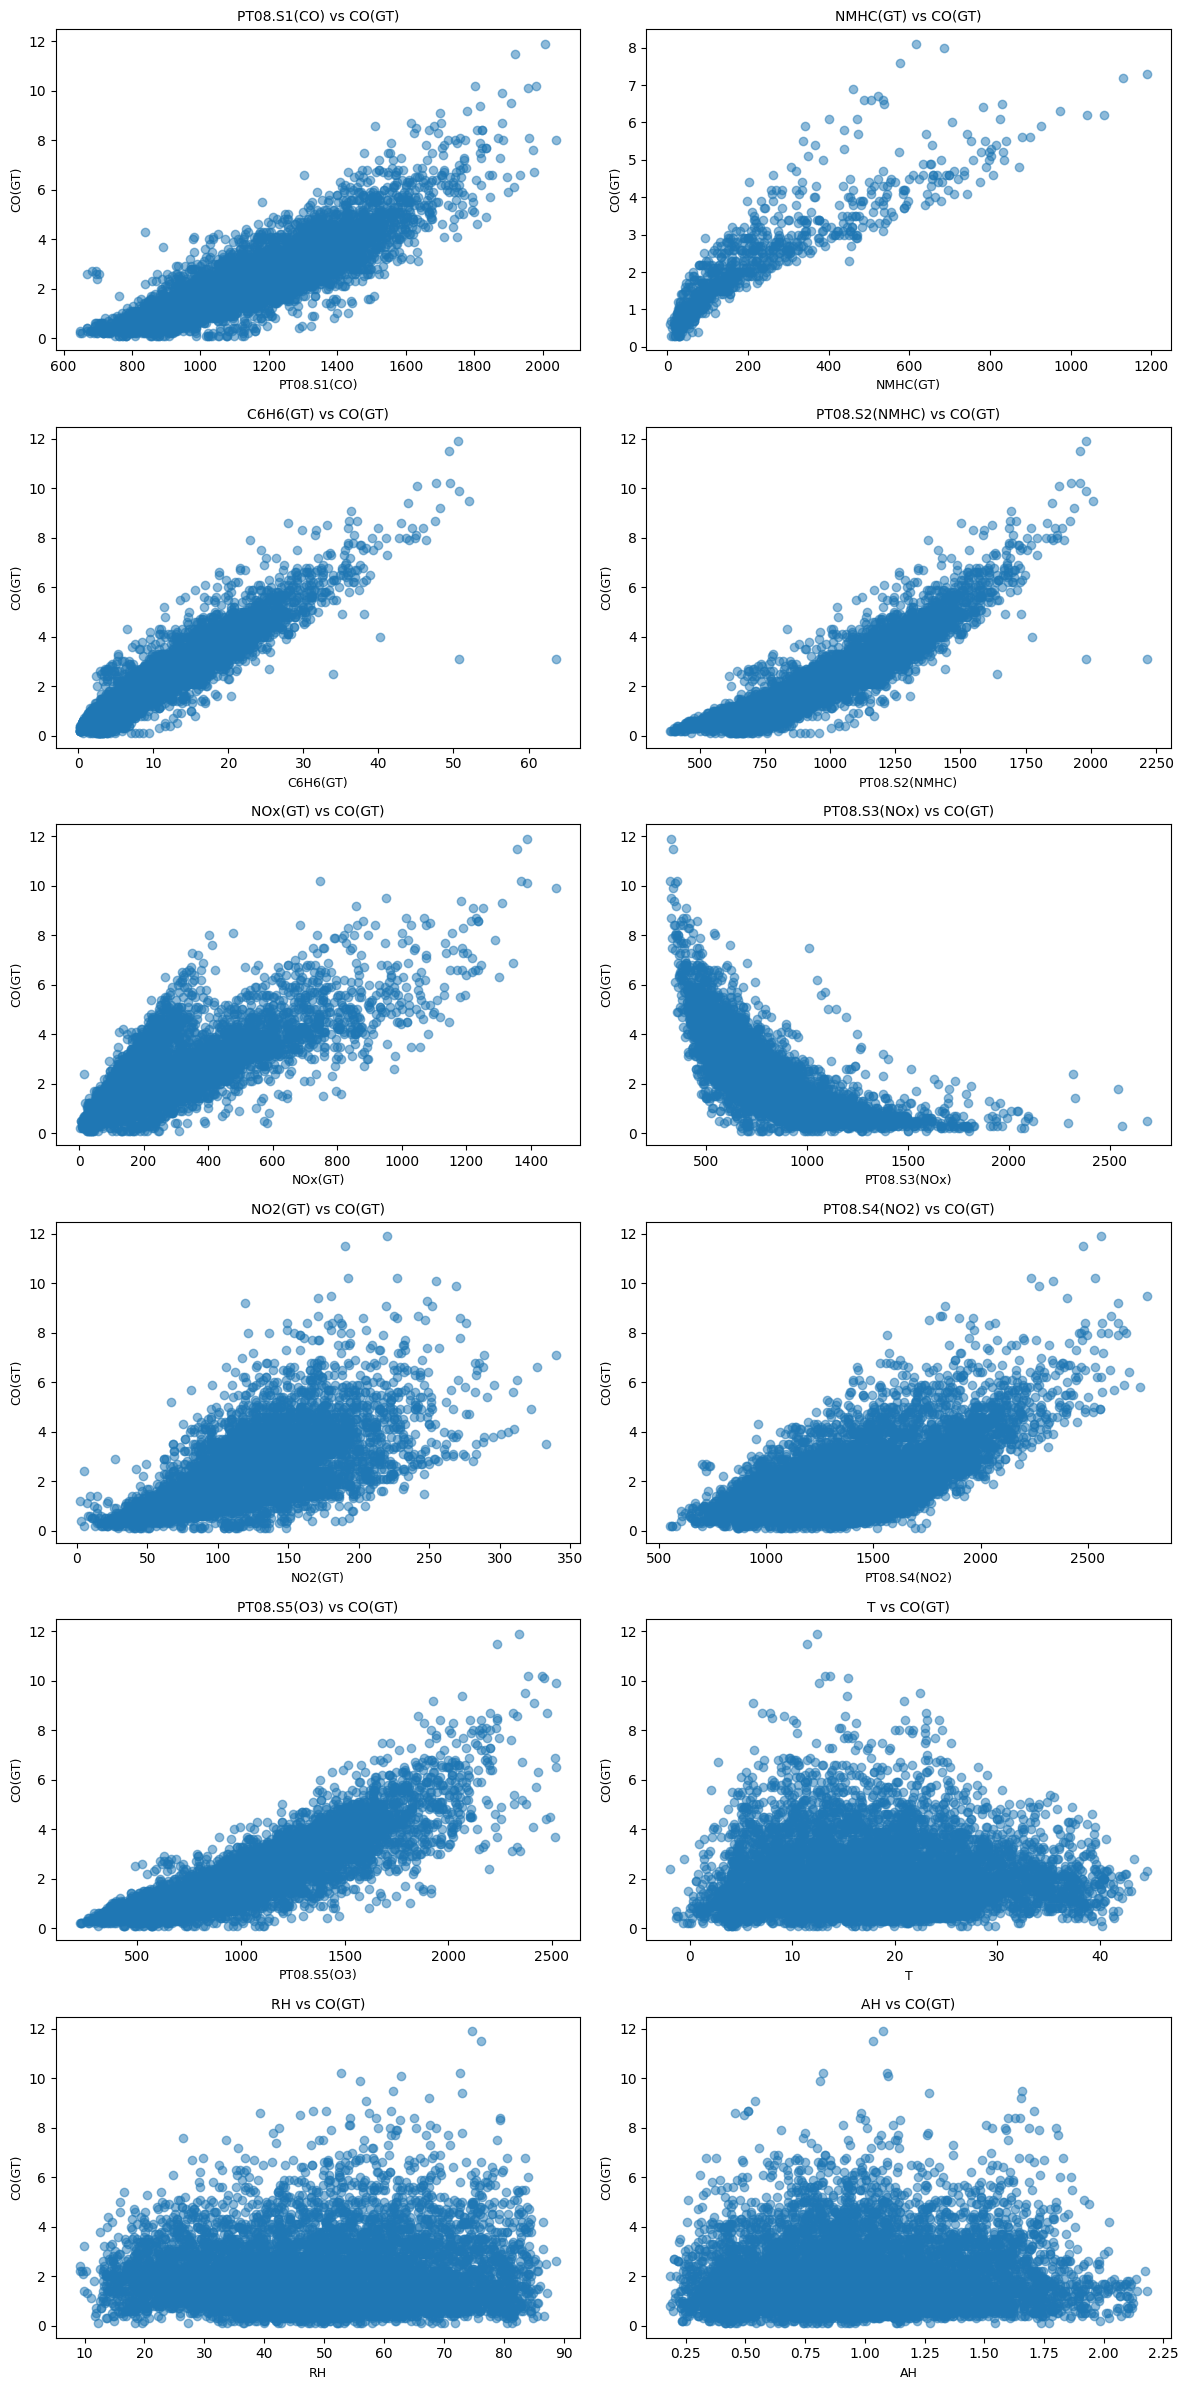

In [7]:
import matplotlib.pyplot as plt
import numpy as np

target = "CO(GT)"

# Variáveis numéricas sem a variável-alvo
predictors = [col for col in numeric_features.columns if col != target]

# Número de colunas por linha
n_cols = 2
n_rows = int(np.ceil(len(predictors) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(predictors):
    axes[i].scatter(df_clean[col], df_clean[target], alpha=0.5)
    axes[i].set_title(f"{col} vs {target}", fontsize=10)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel(target, fontsize=9)

# Remover gráficos vazios, se existirem
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Principais observações da análise bivariada

A matriz de correlação e os gráficos de dispersão mostram que as variáveis mais fortemente associadas a `CO(GT)` são sobretudo sensores químicos e outros poluentes atmosféricos.

Destacam-se `C6H6(GT)` e `PT08.S2(NMHC)`, que apresentam correlações positivas muito fortes com a variável-alvo, sugerindo elevada utilidade preditiva. A variável `PT08.S3(NOx)` revelou uma relação inversa forte com `CO(GT)`, sendo uma das associações mais evidentes da análise.

Por outro lado, as variáveis meteorológicas `T`, `RH` e `AH` apresentaram correlações fracas e gráficos de dispersão sem padrão visual claro, indicando menor capacidade explicativa isolada.

## Tratamento de Valores em Falta

Nesta secção é analisada a percentagem de valores em falta por coluna, com o objetivo de definir uma estratégia de tratamento adequada ao dataset.

A decisão de tratamento teve em conta a importância das variáveis, a percentagem de dados ausentes e o impacto potencial na modelação.

In [8]:
missing_count = df_clean.isnull().sum()
missing_percent = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_table = pd.DataFrame({
    "Nulos": missing_count,
    "Percentagem (%)": missing_percent.round(2)
}).sort_values(by="Percentagem (%)", ascending=False)

missing_table[missing_table["Nulos"] > 0]

,Nulos,Percentagem (%)
NMHC(GT),8443,90.23
CO(GT),1683,17.99
NO2(GT),1642,17.55
NOx(GT),1639,17.52
C6H6(GT),366,3.91
PT08.S2(NMHC),366,3.91
PT08.S3(NOx),366,3.91
PT08.S1(CO),366,3.91
T,366,3.91
RH,366,3.91


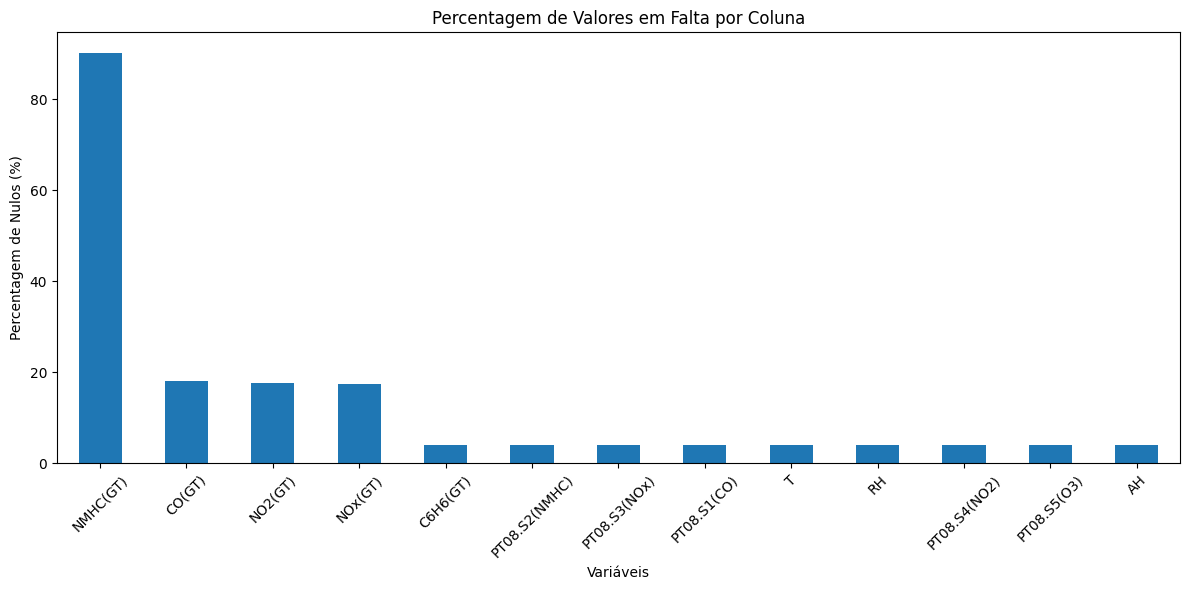

In [9]:
import matplotlib.pyplot as plt

missing_table_filtered = missing_table[missing_table["Nulos"] > 0]

plt.figure(figsize=(12, 6))
missing_table_filtered["Percentagem (%)"].plot(kind="bar")
plt.title("Percentagem de Valores em Falta por Coluna")
plt.xlabel("Variáveis")
plt.ylabel("Percentagem de Nulos (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
df_clean = df_clean.drop(columns=["NMHC(GT)"], errors="ignore")
df_clean = df_clean.dropna(subset=["CO(GT)"])

In [11]:
import numpy as np

for col in df_clean.select_dtypes(include=[np.number]).columns:
    if col != "CO(GT)":
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [12]:
missing_count_final = df_clean.isnull().sum()
missing_percent_final = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_table_final = pd.DataFrame({
    "Nulos": missing_count_final,
    "Percentagem (%)": missing_percent_final.round(2)
}).sort_values(by="Percentagem (%)", ascending=False)

missing_table_final_filtered = missing_table_final[missing_table_final["Nulos"] > 0]

if missing_table_final_filtered.empty:
    print("Não existem valores em falta após o tratamento.")
else:
    display(missing_table_final_filtered)

print("Dimensão final do dataset tratado:", df_clean.shape)

Não existem valores em falta após o tratamento.
Dimensão final do dataset tratado: (7674, 15)


### Principais observações sobre os valores em falta

A análise dos missing values mostrou que a variável `NMHC(GT)` apresentava uma percentagem muito elevada de valores em falta, pelo que foi removida.

As linhas com `CO(GT)` em falta foram eliminadas, por se tratar da variável-alvo, e os restantes valores ausentes foram preenchidos com a mediana. Esta opção foi escolhida por ser mais robusta do que a média na presença de outliers e distribuições assimétricas.

Após a aplicação desta estratégia, deixaram de existir valores em falta no conjunto de dados.

## Verificação de Tipos de Dados e Tratamento de Outliers

Nesta secção são verificados os tipos de dados do dataset e identificados valores atípicos nas variáveis numéricas.

O objetivo é reduzir o impacto de observações extremas que possam enviesar os modelos, mantendo ao mesmo tempo a maior quantidade possível de informação útil.

In [13]:
import pandas as pd
import numpy as np

# Garantir que a coluna temporal está em formato datetime
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"], errors="coerce")

# Garantir que as variáveis numéricas estão em formato numérico
for col in df_clean.columns:
    if col not in ["Date", "Time", "timestamp"]:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean.dtypes

Date                     object
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
timestamp        datetime64[ns]
dtype: object

In [14]:
outlier_summary = []

for col in df_clean.select_dtypes(include=[np.number]).columns:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].shape[0]
    percent_outliers = (outliers / len(df_clean)) * 100

    outlier_summary.append({
        "Variável": col,
        "Nº de Outliers": outliers,
        "Percentagem (%)": round(percent_outliers, 2)
    })

outlier_table = pd.DataFrame(outlier_summary).sort_values(by="Percentagem (%)", ascending=False)

outlier_table

,Variável,Nº de Outliers,Percentagem (%)
4,NOx(GT),464,6.05
5,PT08.S3(NOx),226,2.95
0,CO(GT),215,2.80
2,C6H6(GT),212,2.76
6,NO2(GT),145,1.89
1,PT08.S1(CO),119,1.55
8,PT08.S5(O3),90,1.17
7,PT08.S4(NO2),80,1.04
3,PT08.S2(NMHC),68,0.89
11,AH,46,0.60


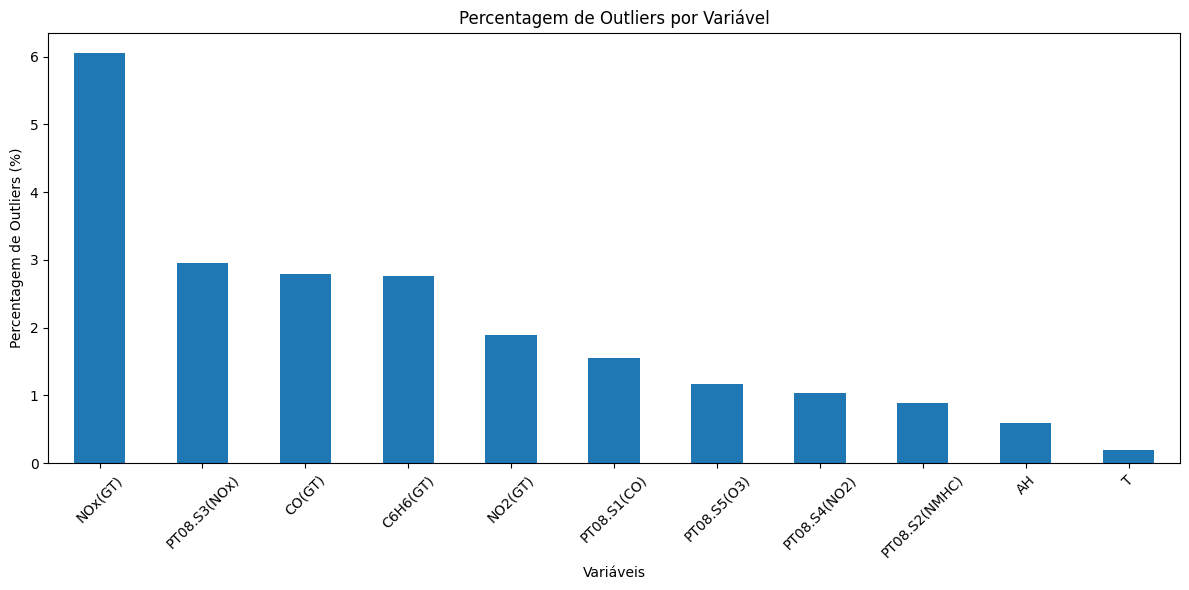

In [15]:
import matplotlib.pyplot as plt

outlier_table_filtered = outlier_table[outlier_table["Nº de Outliers"] > 0]

plt.figure(figsize=(12, 6))
outlier_table_filtered.set_index("Variável")["Percentagem (%)"].plot(kind="bar")
plt.title("Percentagem de Outliers por Variável")
plt.xlabel("Variáveis")
plt.ylabel("Percentagem de Outliers (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if col != "CO(GT)":
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

In [17]:
outlier_summary_final = []

for col in df_clean.select_dtypes(include=[np.number]).columns:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].shape[0]
    percent_outliers = (outliers / len(df_clean)) * 100

    outlier_summary_final.append({
        "Variável": col,
        "Nº de Outliers": outliers,
        "Percentagem (%)": round(percent_outliers, 2)
    })

outlier_table_final = pd.DataFrame(outlier_summary_final).sort_values(by="Percentagem (%)", ascending=False)

outlier_table_final

,Variável,Nº de Outliers,Percentagem (%)
0,CO(GT),215,2.8
1,PT08.S1(CO),0,0.0
2,C6H6(GT),0,0.0
3,PT08.S2(NMHC),0,0.0
4,NOx(GT),0,0.0
5,PT08.S3(NOx),0,0.0
6,NO2(GT),0,0.0
7,PT08.S4(NO2),0,0.0
8,PT08.S5(O3),0,0.0
9,T,0,0.0


### Principais observações sobre outliers e consistência dos dados

Foi confirmada a consistência dos tipos de dados, mantendo `timestamp` em formato temporal e as restantes variáveis quantitativas em formato numérico.

Os outliers foram identificados através do método do intervalo interquartil (IQR), por se tratar de uma abordagem robusta para variáveis numéricas contínuas. Nesta fase, optou-se por privilegiar uma abordagem quantitativa, com base na contagem e percentagem de valores atípicos por variável, evitando a repetição dos boxplots já apresentados na análise univariada.

Nas variáveis preditoras, foi aplicado clipping, limitando os valores aos intervalos definidos pelo IQR, de modo a reduzir a influência de extremos sem eliminar registos completos.

A variável-alvo `CO(GT)` não foi alterada, uma vez que pode refletir episódios reais de poluição atmosférica e corresponde ao valor que se pretende prever.

## Engenharia de Atributos

Nesta secção são criadas variáveis temporais derivadas a partir de `timestamp`, aplicando posteriormente encoding às variáveis categóricas e escalonamento às variáveis numéricas preditoras.

Optou-se por não aplicar encoding diretamente às colunas `Date` e `Time`, uma vez que estas representam informação temporal bruta e gerariam demasiadas categorias. Em vez disso, foram extraídas variáveis temporais mais interpretáveis e úteis para a modelação.

In [18]:
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"], errors="coerce")

In [19]:
df_clean["hour"] = df_clean["timestamp"].dt.hour
df_clean["day_of_week"] = df_clean["timestamp"].dt.day_name()
df_clean["month"] = df_clean["timestamp"].dt.month.astype(str)

In [20]:
print(df_clean[["hour", "day_of_week", "month"]].head())
print(df_clean[["hour", "day_of_week", "month"]].columns)

   hour day_of_week month
0    18   Wednesday     3
1    19   Wednesday     3
2    20   Wednesday     3
3    21   Wednesday     3
4    22   Wednesday     3
Index(['hour', 'day_of_week', 'month'], dtype='object')


In [21]:
df_clean = pd.get_dummies(
    df_clean,
    columns=["day_of_week", "month"],
    drop_first=True
)

In [22]:
df_clean = df_clean.drop(columns=["Date", "Time", "timestamp"], errors="ignore")

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = [col for col in df_clean.select_dtypes(include=["number"]).columns if col != "CO(GT)"]

df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

A pré-visualização do dataset após a engenharia de atributos mostra que as variáveis numéricas preditoras foram escalonadas, passando a apresentar valores centrados em torno de zero. As variáveis categóricas derivadas de timestamp, como o mês e o dia da semana, foram transformadas através de One-Hot Encoding, originando novas colunas binárias (True/False). A variável-alvo CO(GT) foi mantida na sua escala original.

In [24]:
df_clean.head()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,...,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9
0,2.6,1.209110,0.275832,0.393636,-0.421591,1.036919,-0.023474,0.735764,0.583911,-0.476725,...,False,False,False,True,False,False,False,False,False,False
1,2.0,0.883661,-0.094605,0.038970,-0.778569,1.552663,-0.485284,0.342354,-0.172150,-0.511348,...,False,False,False,True,False,False,False,False,False,False
2,2.2,1.410123,-0.153875,-0.023388,-0.619913,1.404059,-0.001483,0.330522,0.088384,-0.672922,...,False,False,False,True,False,False,False,False,False,False
3,2.2,1.285687,-0.124240,0.011688,-0.387593,1.194265,0.174445,0.416303,0.417884,-0.776790,...,False,False,False,True,False,False,False,False,False,False
4,1.6,0.787940,-0.524311,-0.424823,-0.619913,1.688155,0.042499,0.138253,0.180338,-0.753708,...,False,False,False,True,False,False,False,False,False,False


### Principais observações sobre encoding e escalonamento

A partir da variável `timestamp`, foram criadas variáveis temporais derivadas, nomeadamente `hour`, `day_of_week` e `month`, por se considerar que estas representam a informação temporal de forma mais útil para o modelo do que as colunas originais `Date` e `Time`.

O encoding foi aplicado através de **One-Hot Encoding** às variáveis categóricas derivadas, transformando os diferentes dias da semana e meses em colunas binárias. Esta escolha evita a imposição de uma ordem artificial entre categorias e torna os dados mais adequados a algoritmos de regressão.

Posteriormente, foi realizado o **escalonamento das variáveis numéricas preditoras** com `StandardScaler`, de forma a colocá-las numa escala comparável e reduzir o impacto de diferenças de magnitude entre atributos.

A variável-alvo **`CO(GT)`** não foi escalonada, uma vez que corresponde ao valor que se pretende prever.